# Titanic Dataset Survivor Detector Using 

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance



data_path = "../../../datasets/titanic/train.csv"
raw_df = pd.read_csv(data_path)

df = raw_df.copy().drop(columns = ['Cabin', 'Ticket', 'Name'])


## Checking Out Data

In [85]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


In [86]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(2)
memory usage: 62.8+ KB
None


## Cleaning and Feature Selection

In [87]:
df = pd.get_dummies(df, columns = ['Embarked'], dtype = int)

df['Sex_Encoded'] = df['Sex'].apply(lambda x: 1 if x == 'male' else 0)
df['Family'] = df['SibSp'] + df['Parch']
df['Fare'] = df['Fare'].apply(np.log1p).fillna(df.groupby('Pclass')['Fare'].transform('mean'))
df['Age'] = df['Age'].fillna(df['Age'].median())




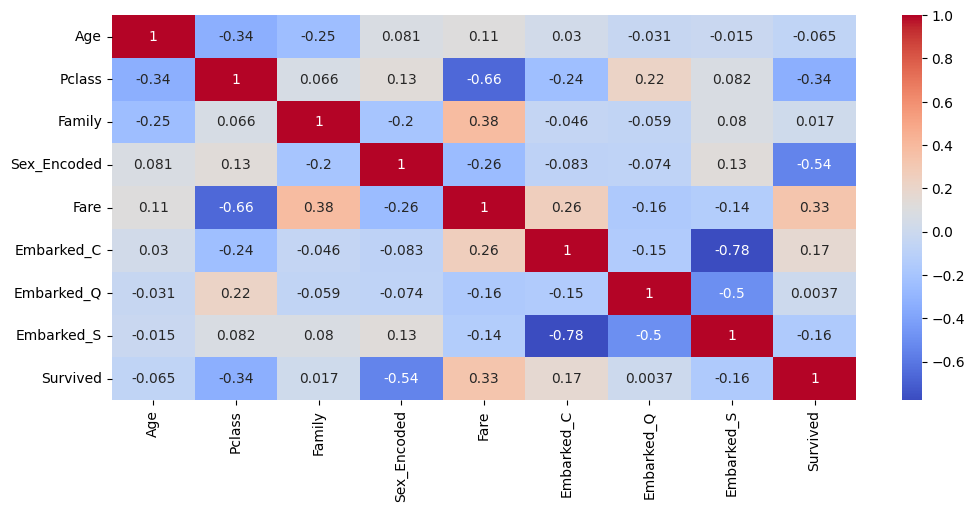

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Sex_Encoded,Family
0,1,0,3,male,22.0,1,0,2.110213,0,0,1,1,1
1,2,1,1,female,38.0,1,0,4.280593,1,0,0,0,1
2,3,1,3,female,26.0,0,0,2.188856,0,0,1,0,0
3,4,1,1,female,35.0,1,0,3.990834,0,0,1,0,1
4,5,0,3,male,35.0,0,0,2.202765,0,0,1,1,0


In [88]:
corr = df[['Age', 'Pclass', 'Family', 'Sex_Encoded', 'Fare', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Survived']].corr()
plt.figure(figsize = (12,5))

sns.heatmap(
    corr,
    annot = True,
    cmap = 'coolwarm',
    cbar = True 
)
plt.show()

df.head()

## Preparing Data

In [89]:
data = df.drop(columns = ['PassengerId', 'SibSp', 'Parch', 'Sex'])
X = data.drop(columns = ['Survived'])
y = data['Survived']


X_train, X_test, y_train, y_test = train_test_split(X.to_numpy(), y.to_numpy(), test_size=0.2, random_state=42)



## Hyperparameter Sweep

In [90]:
results = []
oob_results = []

n_estimators_list = [10, 50, 100, 200]
max_depth_list = [3, 5, None]

for n in n_estimators_list:
    for depth in max_depth_list:
        rf = RandomForestClassifier(
            n_estimators=n,
            max_depth=depth,
            random_state=42,
            oob_score=True,
            bootstrap=True,
            n_jobs=-1
        )

        rf.fit(X_train, y_train)

        preds = rf.predict(X_test)
        acc = accuracy_score(y_test, preds)

        results.append({
            "n_estimators": n,
            "max_depth": depth,
            "accuracy": acc,
            "oob_score": rf.oob_score_,
            "oob_error": 1 - rf.oob_score_
        })


c:\Users\kiet0\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\kiet0\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\kiet0\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


In [91]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="accuracy", ascending=False)

print("Hyperparameter Results:")
print(results_df)

Hyperparameter Results:
    n_estimators  max_depth  accuracy  oob_score  oob_error
8            100        NaN  0.821229   0.782303   0.217697
10           200        5.0  0.821229   0.813202   0.186798
1             10        5.0  0.815642   0.807584   0.192416
7            100        5.0  0.815642   0.817416   0.182584
11           200        NaN  0.815642   0.797753   0.202247
4             50        5.0  0.810056   0.810393   0.189607
3             50        3.0  0.810056   0.799157   0.200843
9            200        3.0  0.804469   0.808989   0.191011
5             50        NaN  0.798883   0.782303   0.217697
2             10        NaN  0.798883   0.775281   0.224719
0             10        3.0  0.793296   0.782303   0.217697
6            100        3.0  0.776536   0.800562   0.199438


In [92]:
trees_range = [10, 25, 50, 75, 100, 150, 200, 300]

for n in trees_range:
    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        oob_score=True,
        bootstrap=True,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    oob_results.append({
        "n_estimators": n,
        "oob_error": 1 - rf.oob_score_
    })

oob_df = pd.DataFrame(oob_results)

c:\Users\kiet0\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


## Plot OOB Error Curve

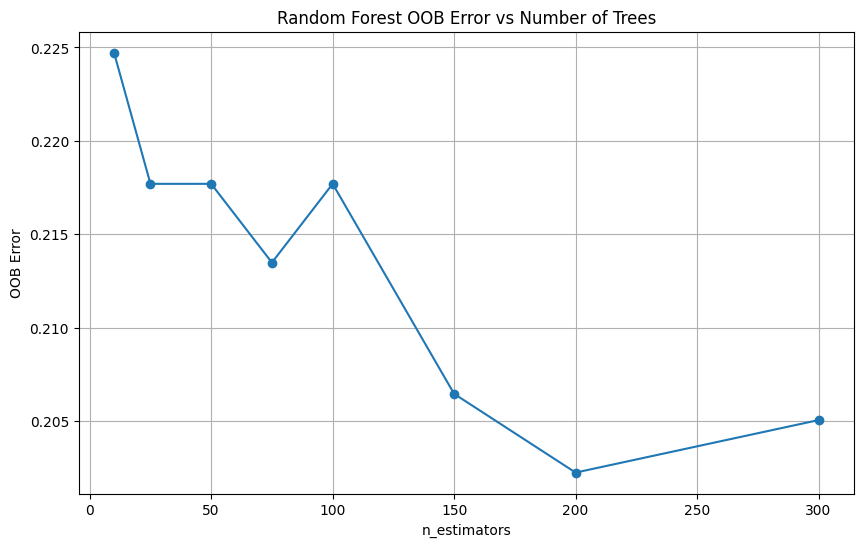

In [93]:
plt.figure(figsize=(10,6))
plt.plot(oob_df["n_estimators"], oob_df["oob_error"], marker="o")
plt.title("Random Forest OOB Error vs Number of Trees")
plt.xlabel("n_estimators")
plt.ylabel("OOB Error")
plt.grid(True)
plt.show()

## Plot Feature Importance

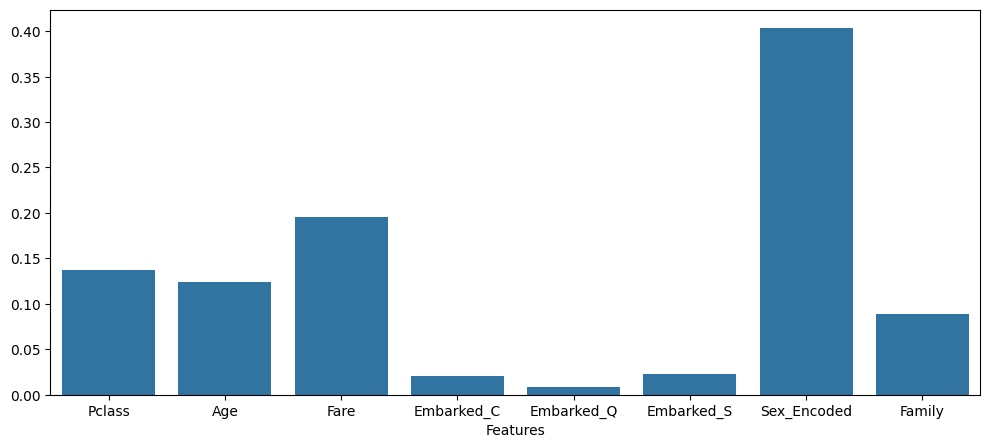

In [96]:
rf = RandomForestClassifier(
            n_estimators= 200,
            max_depth= 5,
            random_state=42,
            oob_score=True,
            bootstrap=True,
            n_jobs=-1
        )

rf.fit(X_train, y_train)





plt.figure(figsize = (12,5))

sns.barplot(x = df.drop(columns = ['PassengerId', 'SibSp', 'Parch', 'Sex', 'Survived']).columns, y = rf.feature_importances_)
plt.xlabel('Features')
plt.show()

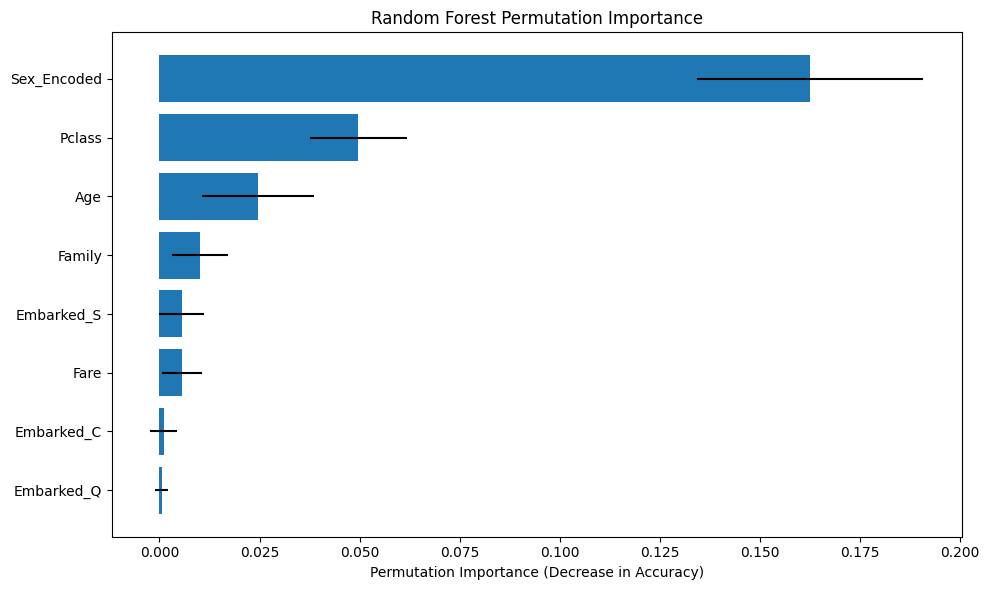

In [97]:
result = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

sorted_idx = result.importances_mean.argsort()

feature_names = X.columns


plt.figure(figsize=(10, 6))

plt.barh(
    np.arange(len(sorted_idx)),
    result.importances_mean[sorted_idx],
    xerr=result.importances_std[sorted_idx]
)

plt.yticks(
    np.arange(len(sorted_idx)),
    feature_names[sorted_idx]
)

plt.xlabel("Permutation Importance (Decrease in Accuracy)")
plt.title("Random Forest Permutation Importance")
plt.tight_layout()
plt.show()